<a id="top"></a>

<div style="background:linear-gradient(135deg,#1a3c6b 0%,#2e6da4 100%);padding:40px 40px 30px;border-radius:12px;margin-bottom:8px">
<h1 style="color:#ffffff;margin:0 0 8px;font-size:2.0em;font-weight:700">
  AllLife Bank &mdash; Credit Card Customer Segmentation
</h1>
<p style="color:#c5d8f0;margin:0 0 18px;font-size:1.05em">
  Unsupervised Learning Project &nbsp;|&nbsp; MIT AAIDSP Elective &nbsp;|&nbsp;
  <strong style="color:#fff">30 Marks</strong>
</p>
<hr style="border:none;border-top:1px solid rgba(255,255,255,0.25);margin:0 0 18px">
<table style="color:#c5d8f0;border-collapse:collapse;font-size:0.92em;width:100%">
<tr><td style="padding:3px 20px 3px 0;font-weight:600">Techniques</td>
    <td>EDA &middot; IQR Winsorization &middot; Log Transform &middot; VIF &middot; PCA
        &middot; K-Means &middot; GMM &middot; K-Medoids</td></tr>
<tr><td style="padding:3px 20px 3px 0;font-weight:600">Dataset</td>
    <td>Credit Card Customer Data &mdash; 660 customers, 5 behavioural features
        (post-cleaning: 655)</td></tr>
<tr><td style="padding:3px 20px 3px 0;font-weight:600">Objective</td>
    <td>Identify natural customer segments to enable personalised marketing
        and service-delivery improvements</td></tr>
<tr><td style="padding:3px 20px 3px 0;font-weight:600">Random Seed</td>
    <td>42 (all stochastic steps)</td></tr>
</table>
</div>

---
## Table of Contents

1. [Introduction & Dataset Overview](#sec-intro)
2. [Setup &mdash; Libraries & Data Loading](#sec-setup)
3. [Data Overview & Sanity Checks](#sec-overview)
4. [Exploratory Data Analysis (EDA)](#sec-eda)
   - 4.1 [Cleaned Dataset & Summary Statistics](#sec-eda-summary)
   - 4.2 [Outlier Detection &mdash; Univariate Boxplots](#sec-eda-outliers)
   - 4.3 [Bivariate Analysis](#sec-eda-bivariate)
   - 4.4 [Distribution & Skewness Analysis](#sec-eda-skewness)
5. [Data Preprocessing](#sec-preprocessing)
   - 5.1 [IQR Winsorization](#sec-prep-winsor)
   - 5.2 [Log Transformation of Avg_Credit_Limit](#sec-prep-log)
   - 5.3 [Multicollinearity Check &mdash; VIF](#sec-prep-vif)
   - 5.4 [Feature Scaling (StandardScaler)](#sec-prep-scaling)
   - 5.5 [PCA &mdash; Dimensionality Reduction](#sec-prep-pca)
6. [K-Means Clustering](#sec-kmeans)
   - 6.1 [Elbow Curve & Silhouette Analysis](#sec-kmeans-elbow)
   - 6.2 [K-Means Cluster Profiles](#sec-kmeans-profiles)
7. [Gaussian Mixture Model (GMM)](#sec-gmm)
   - 7.1 [GMM Model Selection (BIC / AIC)](#sec-gmm-selection)
   - 7.2 [GMM Cluster Profiles](#sec-gmm-profiles)
   - 7.3 [K-Means vs GMM Comparison](#sec-gmm-compare)
8. [K-Medoids](#sec-kmedoids)
   - 8.1 [K-Medoids Clustering & Profiles](#sec-kmedoids-cluster)
   - 8.2 [K-Means vs K-Medoids Comparison](#sec-kmedoids-compare)
9. [Conclusions & Business Recommendations](#sec-conclusions)
10. [Appendix &mdash; Export](#sec-appendix)

---

<a id="sec-intro"></a>
## **1. Introduction & Dataset Overview**

# **Unsupervised Learning Project: AllLife Bank Customer Segmentation**

# **Marks: 30**

Welcome to the project on Unsupervised Learning. We will be using **Credit Card Customer Data** for this project.

--------------------------------
## **Context**
-------------------------------

**AllLife Bank wants to focus on its credit card customer base** in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers.

Another insight from the market research was that the customers perceive the support services of the bank poorly. Based on this, the operations team wants to upgrade the service delivery model, to ensure that customers' queries are resolved faster. The head of marketing and the head of delivery, both decide to reach out to the Data Science team for help.


----------------------------
## **Objective**
-----------------------------

**Identify different segments in the existing customer base**, taking into account their spending patterns as well as past interactions with the bank.

--------------------------
## **About the data**
--------------------------

Data is available on customers of the bank with their credit limit, the total number of credit cards the customer has, and different channels through which the customer has contacted the bank for any queries. These different channels include visiting the bank, online, and through a call center.

- **Sl_no** - Customer Serial Number
- **Customer Key** - Customer identification
- **Avg_Credit_Limit**	- Average credit limit (currency is not specified, you can make an assumption around this)
- **Total_Credit_Cards** - Total number of credit cards
- **Total_visits_bank**	- Total bank visits
- **Total_visits_online** - Total online visits
- **Total_calls_made** - Total calls made

The dataset **`Credit Card Customer Data.xlsx`** contains information on **660 credit card customers** of AllLife Bank. Each row describes a single customer using the following columns:

| Column | Description |
|---|---|
| `Sl_No` | Serial number (row identifier — not predictive) |
| `Customer Key` | Unique customer identifier (not predictive) |
| `Avg_Credit_Limit` | Average credit limit across all the customer's credit cards |
| `Total_Credit_Cards` | Total number of credit cards held by the customer |
| `Total_visits_bank` | Number of times the customer visited a bank branch |
| `Total_visits_online` | Number of times the customer used online banking |
| `Total_calls_made` | Number of calls the customer made to the bank |

The two identifier columns (`Sl_No`, `Customer Key`) carry no behavioural signal and are dropped before analysis. The five remaining features capture **spending capacity** (credit limit, number of cards) and **interaction channel preference** (bank visits, online visits, calls) — exactly the dimensions the marketing and operations teams care about.

<a id="sec-setup"></a>
## **2. Setup — Libraries & Data Loading**

In [3]:
# Install dependencies (pyclustering, statsmodels)
!pip install pyclustering
!pip install statsmodels -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=0a524481b92fb57a51fddebb362b2ae726cae642f0165a53e1da8460dd1a791a
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


In [4]:
# Import all libraries
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Preprocessing & dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from pyclustering.cluster.kmedoids import kmedoids

# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Housekeeping
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Global plotting style
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load dataset and preview first rows
df = pd.read_excel('/content/drive/MyDrive/MIT_AAIDSP_2026/Elective Project/Credit Card Customer Data.xlsx')
print("Shape:", df.shape)
df.head()

Shape: (660, 7)


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


<a id="sec-overview"></a>
## **3. Data Overview & Sanity Checks**

In [7]:
# Inspect dtypes, missing values, duplicate rows/keys, and summary statistics
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nDuplicate Customer Keys:", df['Customer Key'].duplicated().sum())
df.describe()

Data Types:
 Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: object

Missing Values:
 Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

Duplicate Rows: 0

Duplicate Customer Keys: 5


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


**Observations:**

The raw dataset contains **660 rows x 7 columns**. A standard `isnull()` check confirms **zero missing values** across all columns — no imputation is required. A row-level `duplicated()` check returns 0 duplicate rows, but a targeted check on `Customer Key` reveals **5 duplicate keys**: five serial numbers reference the same customer identifier. These are removed (keeping the first occurrence), yielding **655 unique customers** for all downstream analysis.

`Sl_No` and `Customer Key` are identifier columns that carry no behavioural signal and are dropped before analysis. The five remaining analytical features capture two business dimensions:

- **Spending capacity:** `Avg_Credit_Limit` (mean $34,574 across raw 660 rows; highly right-skewed, max = $200,000) and `Total_Credit_Cards` (mean 4.71; range 1-10).
- **Channel interaction preference:** `Total_visits_bank` (range 0-5), `Total_visits_online` (range 0-15, right-skewed), `Total_calls_made` (range 0-10).

The wide disparity between the credit limit mean and median — and the extreme right tail — immediately flags skewness and outlier treatment as a required preprocessing step.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-eda"></a>
## **4. Exploratory Data Analysis (EDA)**

<a id="sec-eda-summary"></a>
### **4.1 Cleaned Dataset & Summary Statistics**

Rows after removing duplicate Customer Keys: 655 (removed 5)
Analysis columns: ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

Summary Statistics:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,655.00,655.00,655.00,655.00,655.00
mean,34242.75,4.69,2.40,2.61,3.60
std,37240.90,2.17,1.63,2.94,2.87
min,3000.00,1.00,0.00,0.00,0.00
25%,10000.00,3.00,1.00,1.00,1.00
50%,18000.00,5.00,2.00,2.00,3.00
75%,48000.00,6.00,4.00,4.00,5.00
max,200000.00,10.00,5.00,15.00,10.00


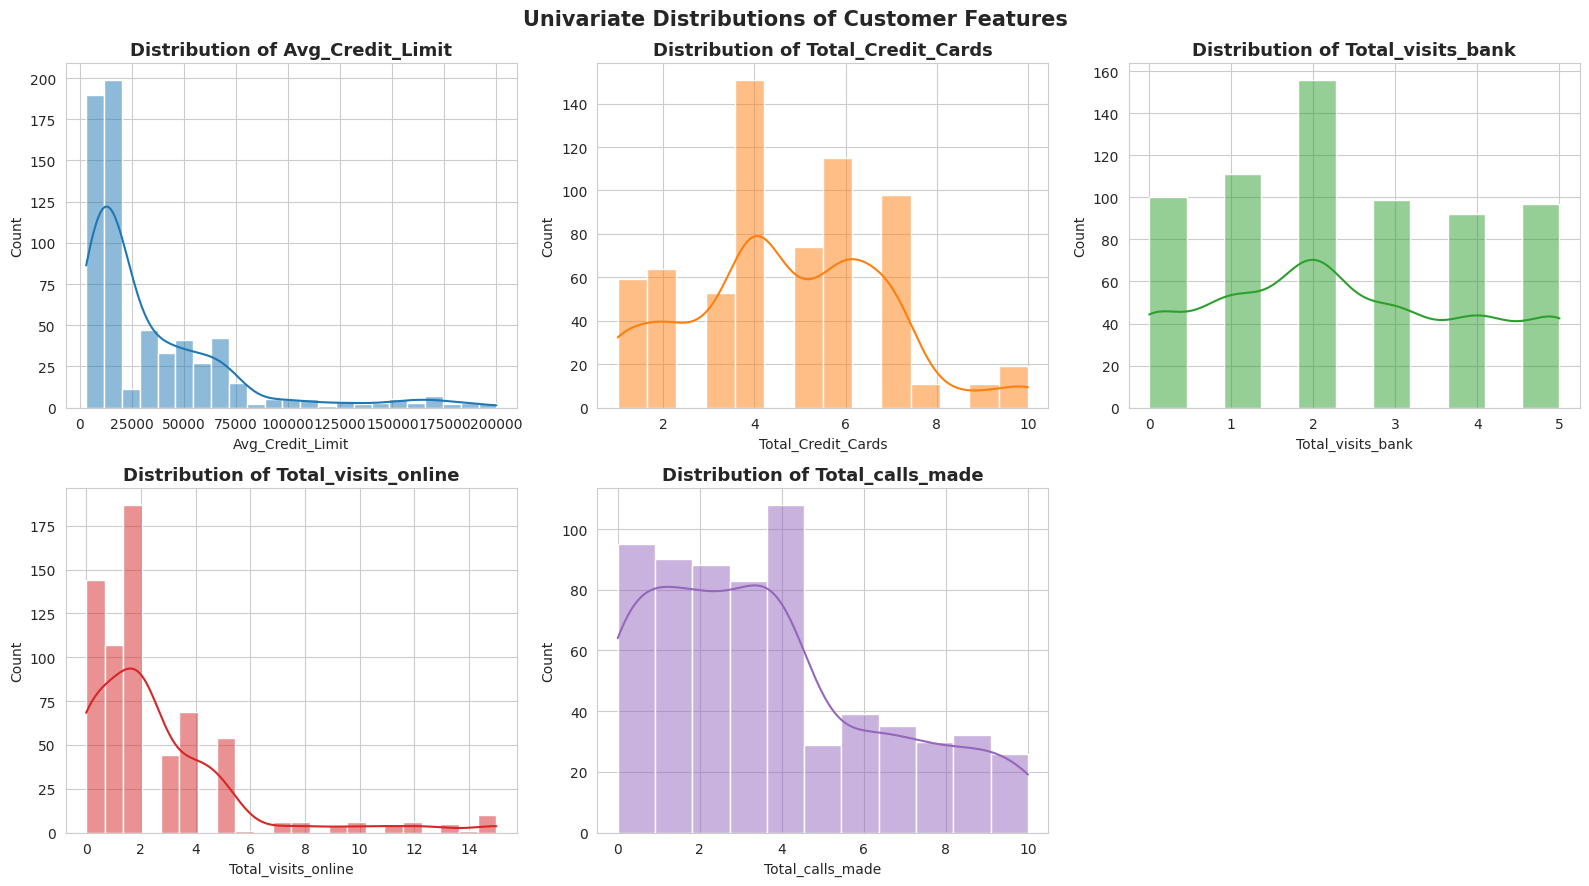

In [9]:
# Remove duplicate Customer Keys and print summary statistics on cleaned data
# Remove duplicate customer keys
df_clean = df.drop_duplicates(subset='Customer Key', keep='first').copy()
print(f"Rows after removing duplicate Customer Keys: {len(df_clean)} (removed {len(df)-len(df_clean)})")

# Drop non-analytical columns
df_analysis = df_clean.drop(columns=['Sl_No', 'Customer Key'])
print(f"Analysis columns: {list(df_analysis.columns)}")

# Summary statistics
print("\nSummary Statistics:")
display(df_analysis.describe().round(2))

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(df_analysis.columns):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color=sns.color_palette('tab10')[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
# Hide the empty 6th subplot
axes[5].axis('off')
plt.suptitle('Univariate Distributions of Customer Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**

After removing the 5 duplicate Customer Keys the working dataset has **655 customers x 5 analytical features**.

Key findings from the summary statistics:

- **Avg_Credit_Limit** is strongly right-skewed: mean ($34,243) sits well above the median ($18,000), and the maximum ($200,000) is roughly 4x the 75th-percentile value ($48,000) — a small cohort of very high-credit customers inflates the mean.
- **Total_Credit_Cards** is more symmetric (mean 4.69, median 5.0; range 1-10).
- **Total_visits_bank** is bounded and relatively narrow (0-5, median 2), suggesting most customers visit branches infrequently.
- **Total_visits_online** spans 0-15 with mean 2.61 and median 2 — a long right tail of power digital users.
- **Total_calls_made** has mean 3.60 and median 3 (range 0-10) — moderate rightward skew.

These distributional differences — especially the extreme skew of `Avg_Credit_Limit` and `Total_visits_online` — motivate the IQR winsorization and log-transform preprocessing steps that follow in Section 5.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-eda-outliers"></a>
### **4.2 Outlier Detection — Univariate Boxplots**

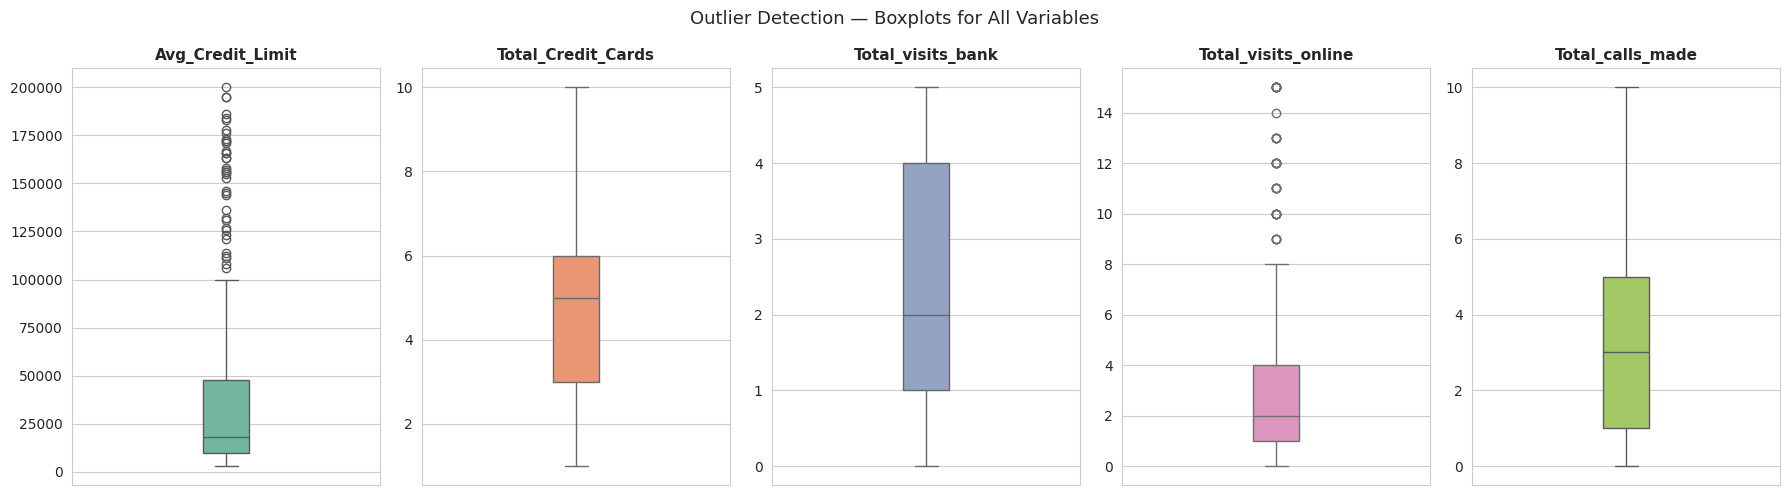

In [37]:
# Univariate boxplots on raw (pre-winsorization) cleaned data
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

# Iterate over the original feature columns in df_clean for plotting
feature_cols_for_boxplot = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
colors = sns.color_palette('Set2', 5)  # <-- Get 5 different colors
for i, col in enumerate(feature_cols_for_boxplot):
    sns.boxplot(y=df_analysis[col], ax=axes[i], color=colors[i], width=0.15)  # <-- Use colors[i]
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('')
plt.suptitle('Outlier Detection — Boxplots for All Variables', fontsize=13)
plt.tight_layout()
plt.show()

**Observations:**

The boxplots on the raw (pre-processed) data reveal the nature and extent of outliers before any treatment is applied:

- **Avg_Credit_Limit** shows the most striking outliers — multiple customers have credit limits approaching $200,000, far above the IQR fence near $48,000. These represent a genuine high-value segment.
- **Total_visits_online** has pronounced upper outliers (up to 15 visits), reflecting a small group of highly digitally active customers.
- **Total_calls_made** has moderate upper outliers (up to 10 calls), consistent with a subset of high-support-demand customers.
- **Total_Credit_Cards** and **Total_visits_bank** show few or no significant outliers.

These observations confirm that outliers are **not data entry errors but genuine extreme customer behaviours** that define meaningful segments. Removing these customers would discard exactly the signals that make segmentation valuable. Instead, Section 5.1 applies **IQR winsorization** (capping rather than removing) to limit their distortionary effect on Euclidean distance calculations while retaining every customer row in the dataset.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-eda-bivariate"></a>
### **4.3 Bivariate Analysis**

**Bivariate Analysis**

Next we study relationships between features. The correlation heatmap quantifies linear association (important for the VIF/multicollinearity check later), the scatter plots probe specific hypotheses about spending vs. channel behaviour, and the pair plot gives a full pairwise overview.

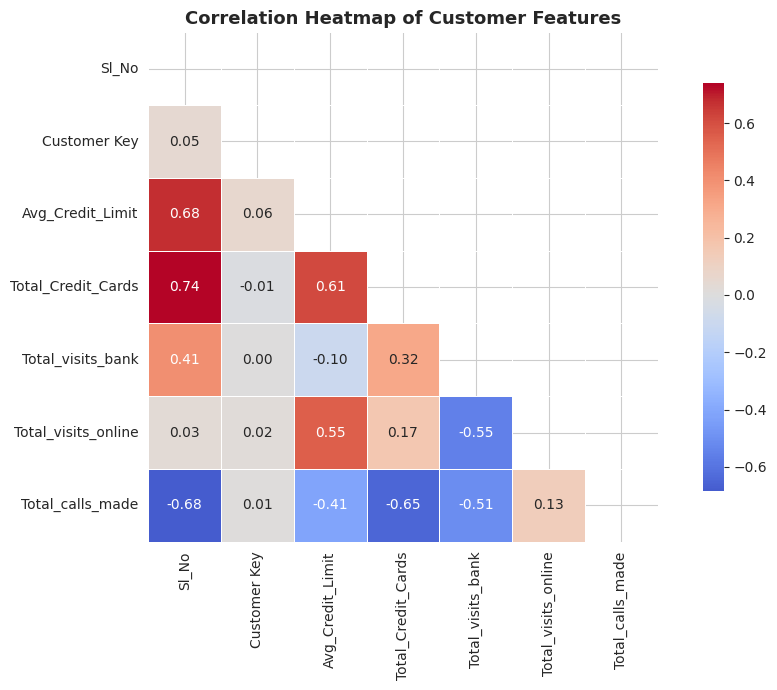

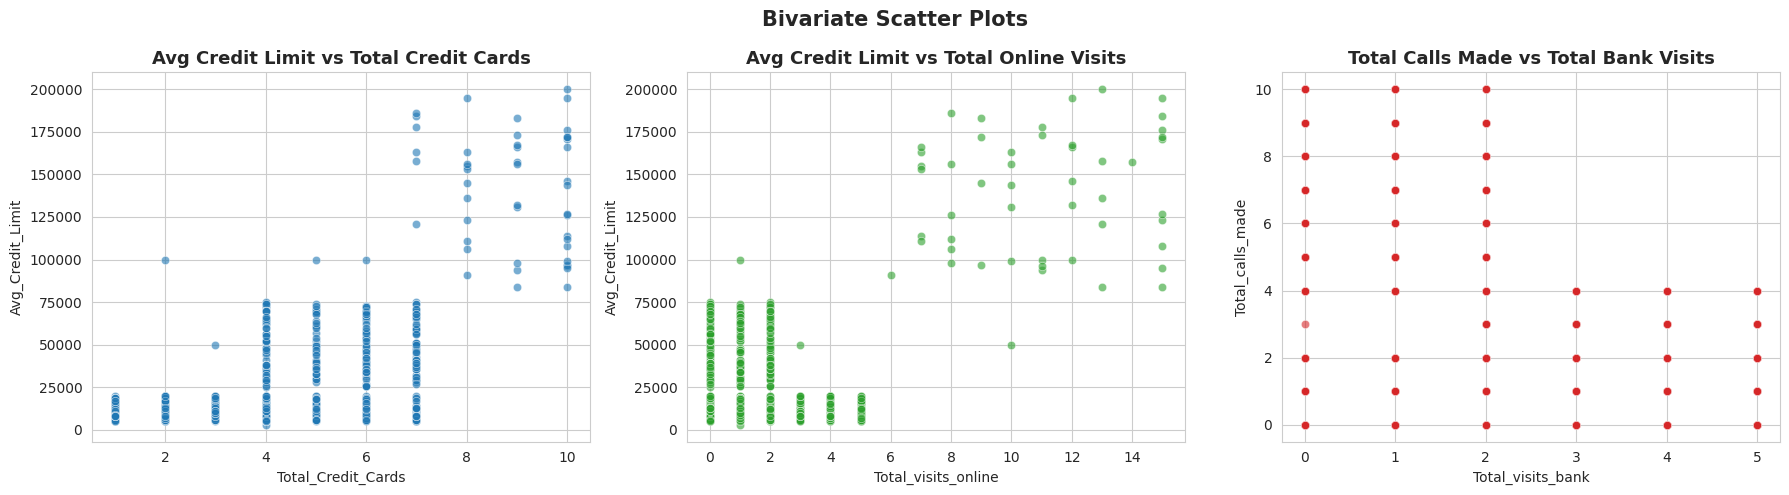

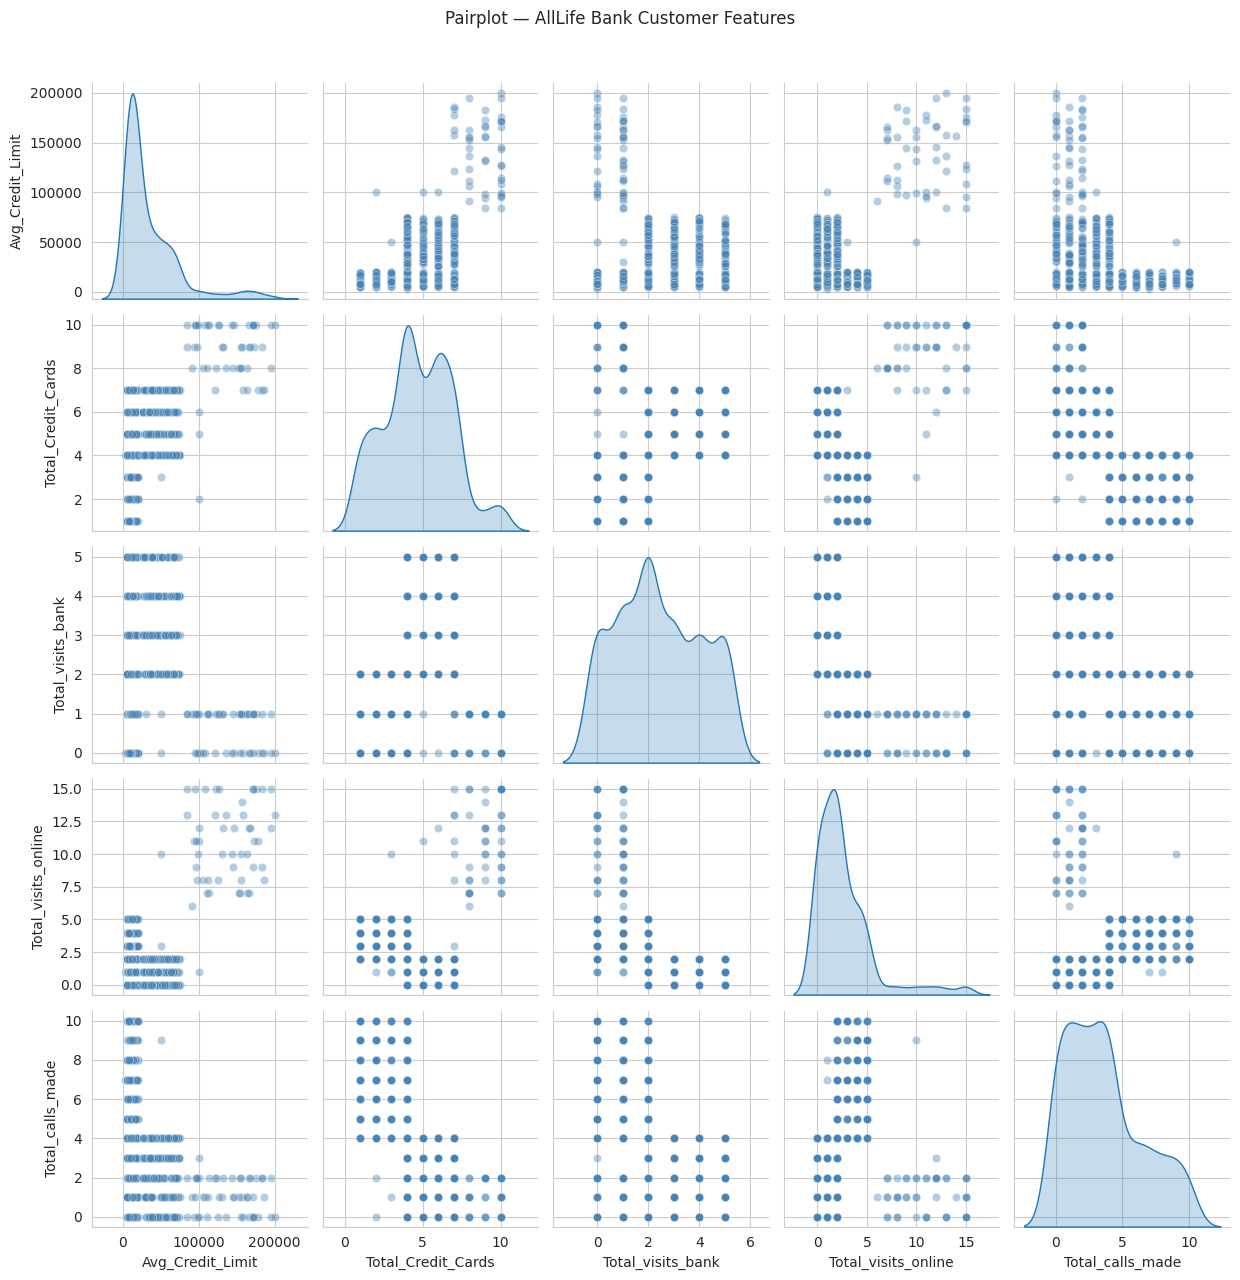


Correlation Matrix:


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Sl_No,1.000,0.049,0.678,0.739,0.409,0.031,-0.684
Customer Key,0.049,1.000,0.058,-0.013,0.003,0.018,0.009
Avg_Credit_Limit,0.678,0.058,1.000,0.611,-0.097,0.552,-0.413
Total_Credit_Cards,0.739,-0.013,0.611,1.000,0.316,0.168,-0.649
Total_visits_bank,0.409,0.003,-0.097,0.316,1.000,-0.552,-0.509
Total_visits_online,0.031,0.018,0.552,0.168,-0.552,1.000,0.129
Total_calls_made,-0.684,0.009,-0.413,-0.649,-0.509,0.129,1.000


In [11]:
# Correlation heatmap, scatter plots, and pair plot
# Correlation heatmap with upper triangle masked
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Customer Features')
plt.tight_layout()
plt.show()

# Targeted scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_clean, x='Total_Credit_Cards', y='Avg_Credit_Limit',
                ax=axes[0], color='tab:blue', alpha=0.6)
axes[0].set_title('Avg Credit Limit vs Total Credit Cards')

sns.scatterplot(data=df_clean, x='Total_visits_online', y='Avg_Credit_Limit',
                ax=axes[1], color='tab:green', alpha=0.6)
axes[1].set_title('Avg Credit Limit vs Total Online Visits')

sns.scatterplot(data=df_clean, x='Total_visits_bank', y='Total_calls_made',
                ax=axes[2], color='tab:red', alpha=0.6)
axes[2].set_title('Total Calls Made vs Total Bank Visits')

plt.suptitle('Bivariate Scatter Plots', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplots of all five features
sns.pairplot(df_analysis, diag_kind='kde', plot_kws={'alpha':0.4, 'color':'steelblue'})
plt.suptitle('Pairplot — AllLife Bank Customer Features', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
display(corr.round(3))

**Observations:**

The correlation matrix and visual plots reveal two structurally important patterns that will re-emerge as the dominant axes in PCA and clustering:

**Financial-tier axis (positive correlations):**
- `Avg_Credit_Limit` &harr; `Total_Credit_Cards`: **r = +0.611** — higher-credit customers hold more cards.
- `Avg_Credit_Limit` &harr; `Total_visits_online`: **r = +0.552** — high-credit customers are significantly more digitally engaged.
- `Total_Credit_Cards` &harr; `Total_visits_bank`: **r = +0.316** — more cards correlates weakly with more branch visits.

**Channel-preference axis (negative correlations):**
- `Total_calls_made` &harr; `Total_Credit_Cards`: **r = -0.649** (strongest negative) — lower-credit customers with fewer cards rely heavily on call-centre support.
- `Total_visits_bank` &harr; `Total_visits_online`: **r = -0.552** — bank and online visits are substitutes; customers strongly favour one channel over the other.
- `Total_calls_made` &harr; `Total_visits_bank`: **r = -0.509** — customers who call frequently also tend not to visit branches.
- `Total_calls_made` &harr; `Avg_Credit_Limit`: **r = -0.413** — lower-credit customers generate the most support calls.

**Business implication:** These two axes — *financial tier* and *channel preference* — together explain most of the structure in the data. The multicollinearity they create (multiple features moving together) is a pre-condition for PCA to compress the 5 features into fewer, uncorrelated components without information loss.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-eda-skewness"></a>
### **4.4 Distribution & Skewness Analysis**

In [12]:
# Compute and display skewness of all features before outlier treatment
# Skewness of each feature before treatment
skew_before = df_analysis.skew().sort_values(ascending=False)
print("Skewness BEFORE outlier treatment (>|1| indicates high skew):")
display(skew_before.round(3).to_frame('Skewness'))

Skewness BEFORE outlier treatment (>|1| indicates high skew):


,Skewness
Total_visits_online,2.227
Avg_Credit_Limit,2.209
Total_calls_made,0.650
Total_Credit_Cards,0.160
Total_visits_bank,0.140


**Observations:**

Two features are **highly right-skewed** (|skew| > 1, the conventional threshold for significant asymmetry):

- **Total_visits_online: skew = 2.23** — the majority of customers have 0-4 online visits; a long tail of power-users (up to 15) creates severe positive skew.
- **Avg_Credit_Limit: skew = 2.21** — the mass of customers clusters in the $3k-$50k range, but the tail extending to $200k drives high skew.

The remaining three features are close to symmetric — `Total_calls_made` (0.65), `Total_Credit_Cards` (0.16), `Total_visits_bank` (0.14).

**Why this matters for clustering:** K-Means, GMM and K-Medoids all use distance metrics (Euclidean or equivalent). In a heavily skewed distribution a few outlier data points can disproportionately dominate distance calculations, pulling cluster centroids toward the extreme tail and causing misclassification of the majority of customers. IQR winsorization (Section 5.1) and log transformation (Section 5.2) are applied to correct this before modelling.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-preprocessing"></a>
## **5. Data Preprocessing**

## **Data Preprocessing**

Clustering quality depends heavily on clean, comparably-scaled inputs. Our preprocessing pipeline has three steps:

1. **Outlier treatment (IQR winsorization):** cap extreme values so they do not dominate distance calculations.
2. **Log transformation:** compress the heavy right-skew of `Avg_Credit_Limit` toward a more symmetric distribution.
3. **Feature scaling (standardization):** put every feature on a common mean-0 / unit-variance scale so no single feature dominates purely because of its magnitude.

We keep a working copy `df_processed` so the original `df_clean` remains available for human-readable cluster profiling later.

<a id="sec-prep-winsor"></a>
### **5.1 Outlier Treatment — IQR Winsorization**

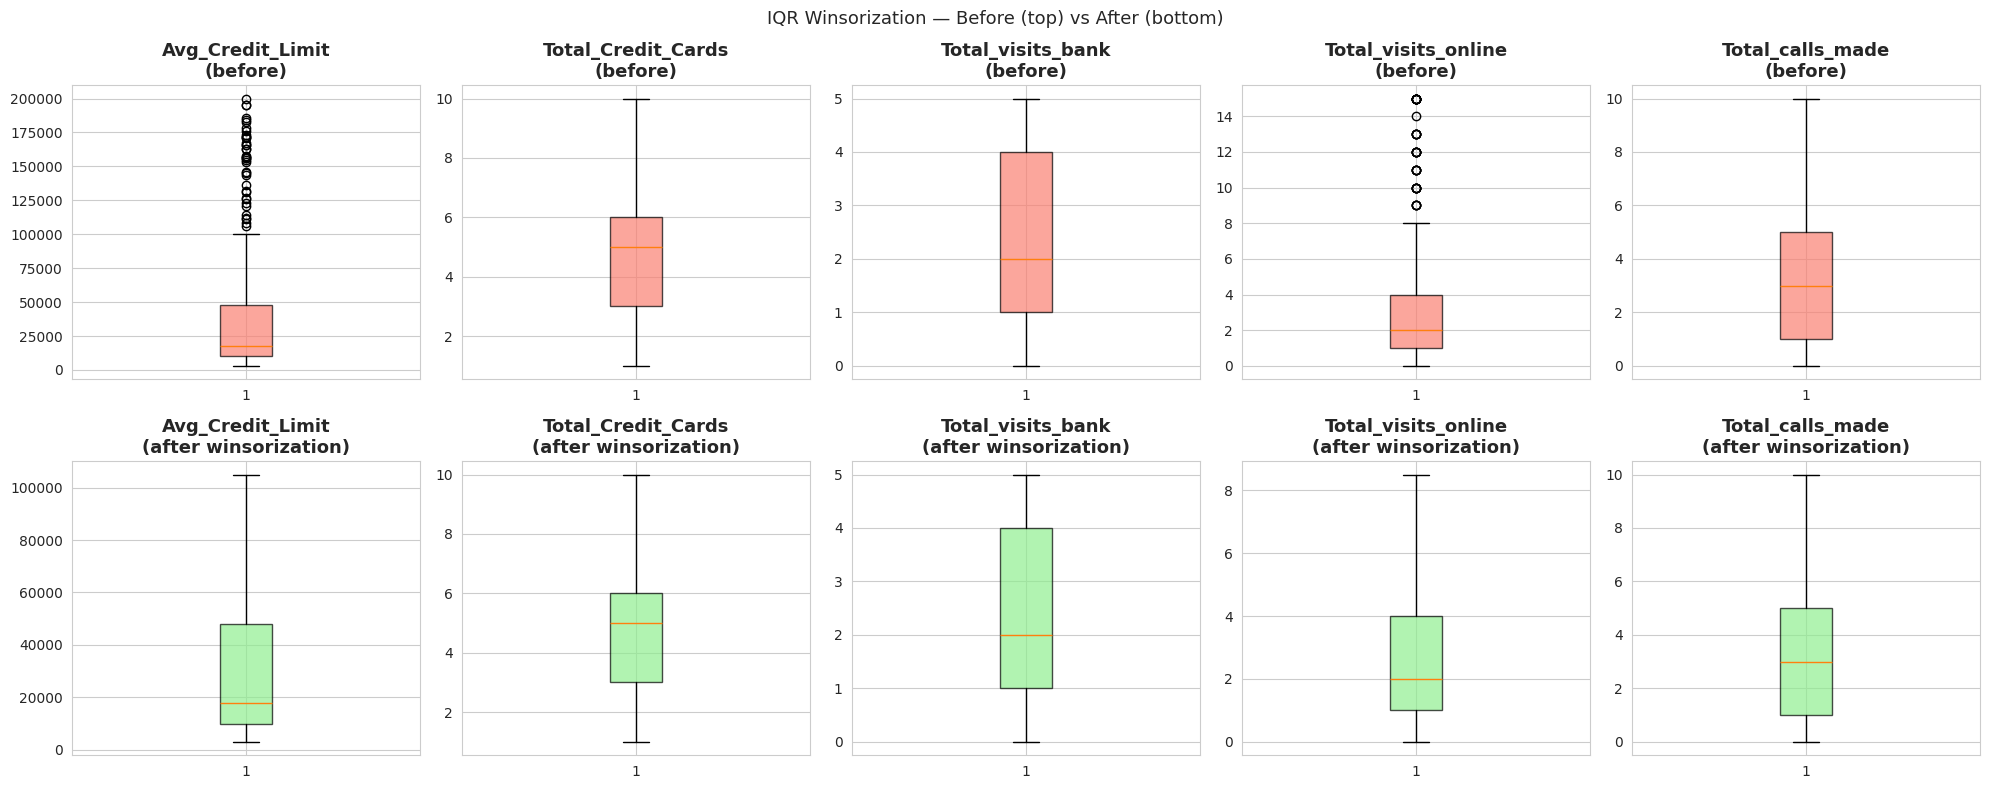

Skewness AFTER winsorization:


,Skewness
Avg_Credit_Limit,1.269
Total_visits_online,1.209
Total_calls_made,0.650
Total_Credit_Cards,0.160
Total_visits_bank,0.140


In [13]:
# Winsorize each feature to its 1.5xIQR whisker bounds and recheck skewness
# Winsorize (cap) each feature to its 1.5*IQR whisker bounds
def winsorize_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return series.clip(lower, upper)

df_processed = df_analysis.copy()
for col in df_processed.columns:
    df_processed[col] = winsorize_iqr(df_processed[col])

# Before/after boxplots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(df_analysis.columns):
    axes[0, i].boxplot(df_analysis[col], patch_artist=True,
                       boxprops=dict(facecolor='salmon', alpha=0.7))
    axes[0, i].set_title(f'{col}\n(before)')
    axes[1, i].boxplot(df_processed[col], patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', alpha=0.7))
    axes[1, i].set_title(f'{col}\n(after winsorization)')
plt.suptitle('IQR Winsorization — Before (top) vs After (bottom)', fontsize=13)
plt.tight_layout()
plt.show()

# Skewness after winsorization
skew_after = df_processed.skew().sort_values(ascending=False)
print("Skewness AFTER winsorization:")
display(skew_after.round(3).to_frame('Skewness'))

**Observations:**

Winsorizing each feature to its 1.5xIQR whisker bounds caps extreme values without removing any customer rows — **all 655 customers are retained**.

The impact on skewness:
- **Total_visits_online**: skew falls from **2.23 → 1.21** (improvement of ~46%).
- **Avg_Credit_Limit**: skew falls from **2.21 → 1.27** (improvement of ~43%).
- The three other features were already near-symmetric and are unchanged.

Despite this improvement, `Avg_Credit_Limit` (skew 1.27) remains moderately right-skewed after capping — credit values span a genuinely wide monetary range. A log transformation is applied next to further reduce asymmetry.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-prep-log"></a>
### **5.2 Log Transformation of Avg_Credit_Limit**

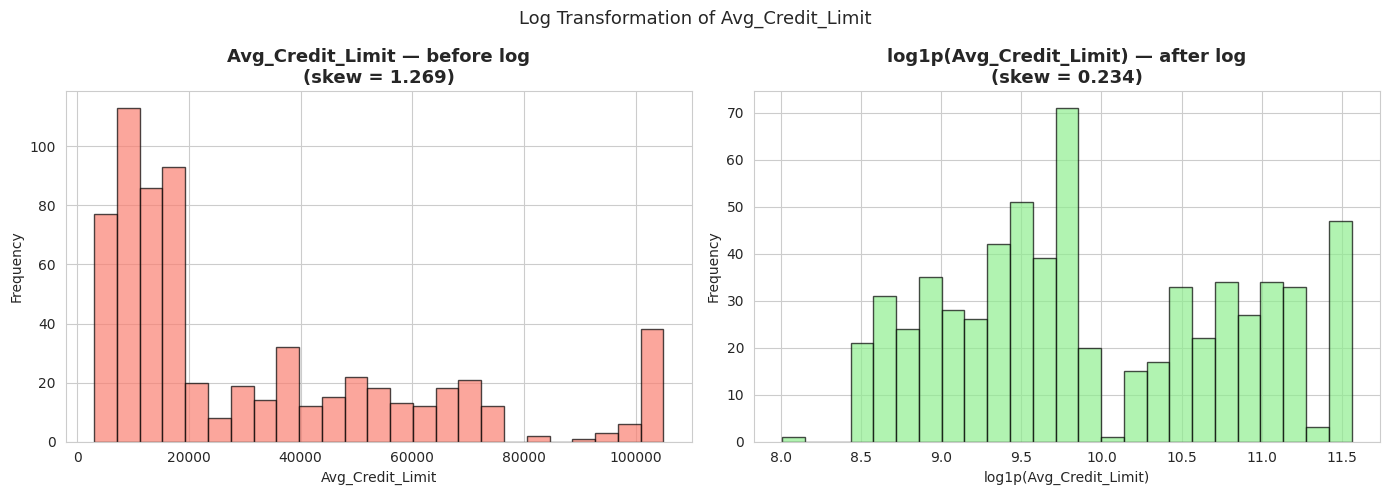

Skewness of Avg_Credit_Limit after log1p: 0.234
df_processed shape: (655, 5)


In [14]:
# Apply np.log1p to winsorized Avg_Credit_Limit and verify skewness
# Log-transform the still-skewed monetary variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_processed['Avg_Credit_Limit'], bins=25, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title(f"Avg_Credit_Limit — before log\n(skew = {df_processed['Avg_Credit_Limit'].skew():.3f})")
axes[0].set_xlabel('Avg_Credit_Limit'); axes[0].set_ylabel('Frequency')

log_credit = np.log1p(df_processed['Avg_Credit_Limit'])
axes[1].hist(log_credit, bins=25, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title(f"log1p(Avg_Credit_Limit) — after log\n(skew = {log_credit.skew():.3f})")
axes[1].set_xlabel('log1p(Avg_Credit_Limit)'); axes[1].set_ylabel('Frequency')
plt.suptitle('Log Transformation of Avg_Credit_Limit', fontsize=13)
plt.tight_layout()
plt.show()

# Apply the log transform to the processed dataframe
df_processed['Avg_Credit_Limit'] = np.log1p(df_processed['Avg_Credit_Limit'])
print("Skewness of Avg_Credit_Limit after log1p:", round(df_processed['Avg_Credit_Limit'].skew(), 3))
print("df_processed shape:", df_processed.shape)

**Observations:**

Applying `np.log1p` to the winsorized `Avg_Credit_Limit` reduces skewness from **1.27 → 0.23** — effectively eliminating the remaining right-tail asymmetry and producing a near-symmetric, approximately bell-shaped distribution. The side-by-side histograms confirm the dramatic compression of the long tail.

`df_processed` (shape 655 x 5) now contains the fully preprocessed feature set: IQR-winsorized on all five variables, and log-transformed on `Avg_Credit_Limit`. All cluster profiles in later sections are reported on **original (untransformed) values** so that monetary figures remain interpretable in dollar terms for business stakeholders.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-prep-vif"></a>
### **5.3 Multicollinearity Check — Variance Inflation Factor (VIF)**

,Feature,VIF
0,Avg_Credit_Limit,26.15
1,Total_Credit_Cards,12.32
2,Total_visits_bank,6.27
3,Total_calls_made,4.44
4,Total_visits_online,3.92


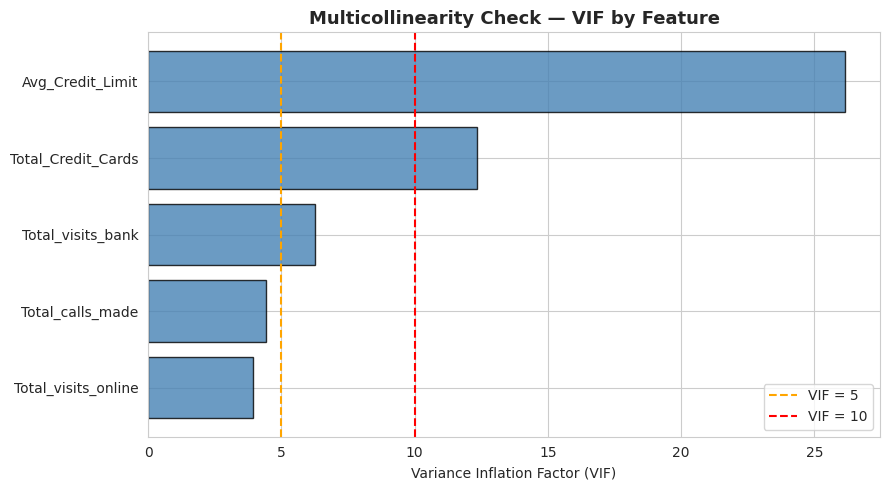

In [15]:
# Compute VIF on preprocessed features
# VIF on the preprocessed features
vif_data = pd.DataFrame()
vif_data['Feature'] = df_processed.columns
vif_data['VIF'] = [variance_inflation_factor(df_processed.values, i)
                   for i in range(df_processed.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
display(vif_data.round(2))

# Horizontal bar plot
plt.figure(figsize=(9, 5))
plt.barh(vif_data['Feature'], vif_data['VIF'], color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(x=5, color='orange', linestyle='--', label='VIF = 5')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10')
plt.xlabel('Variance Inflation Factor (VIF)')
plt.title('Multicollinearity Check — VIF by Feature')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Observations:**

The VIF scores confirm substantial multicollinearity among the five features:

| Feature | VIF | Interpretation |
|---|---|---|
| Avg_Credit_Limit | **26.15** | Severely multicollinear — exceeds threshold of 10 |
| Total_Credit_Cards | **12.32** | Severely multicollinear — exceeds threshold of 10 |
| Total_visits_bank | 6.27 | Moderately multicollinear — above 5 |
| Total_calls_made | 4.44 | Acceptable |
| Total_visits_online | 3.92 | Acceptable |

`Avg_Credit_Limit` (VIF 26.15) and `Total_Credit_Cards` (VIF 12.32) far exceed the conventional threshold of 10, and `Total_visits_bank` (6.27) exceeds the 5-point warning threshold. This mirrors the strong inter-feature correlations found in Section 4.3 (credit limit &harr; cards &harr; online visits &harr; calls).

**Resolution strategy:** Rather than dropping variables — each carries distinct business meaning that should not be discarded — the multicollinearity is addressed by **PCA** (Section 5.5). PCA transforms the correlated features into orthogonal (uncorrelated) principal components, eliminating redundancy while retaining all the underlying information content.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-prep-scaling"></a>
### **5.4 Feature Scaling (StandardScaler)**

In [16]:
# Standardize all features to zero-mean / unit-variance
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_processed)
df_scaled_df = pd.DataFrame(df_scaled, columns=df_processed.columns)
print("Scaled data shape:", df_scaled_df.shape)
print("\nScaled statistics (mean≈0, std≈1):")
display(df_scaled_df.describe().round(3))

Scaled data shape: (655, 5)

Scaled statistics (mean≈0, std≈1):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,655.000,655.000,655.000,655.000,655.000
mean,0.000,-0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001
min,-2.215,-1.703,-1.471,-1.062,-1.257
25%,-0.855,-0.780,-0.859,-0.619,-0.908
50%,-0.191,0.142,-0.246,-0.176,-0.210
75%,0.917,0.604,0.979,0.711,0.488
max,1.801,2.449,1.592,2.706,2.233


**Observations:**

`StandardScaler` transforms all 5 features to **mean ≈ 0, standard deviation ≈ 1** (confirmed by the output above). This step is essential before PCA and distance-based clustering: without scaling, `Avg_Credit_Limit` — which has raw values in the tens of thousands — would numerically dominate Euclidean distance calculations over features like `Total_visits_bank` (range 0-5), regardless of their relative informational importance. After scaling every feature contributes on an equal footing.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-prep-pca"></a>
### **5.5 PCA — Dimensionality Reduction**

,PC,Variance Explained (%),Cumulative Variance (%)
0,PC1,48.42,48.42
1,PC2,30.55,78.97
2,PC3,9.09,88.06
3,PC4,6.40,94.46
4,PC5,5.54,100.00


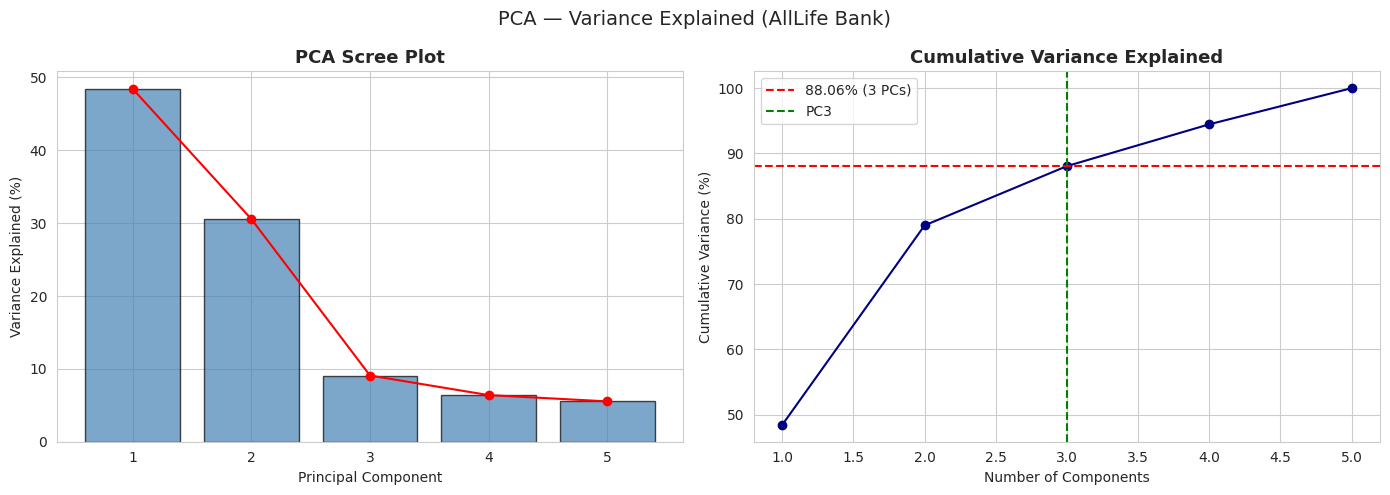


Using 3 PCA components — Cumulative variance: 88.06%


In [17]:
# Fit full PCA, compute explained variance table, and select 3 components
# PCA to determine number of components
pca_full = PCA()
pca_full.fit(df_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Variance table
var_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_var))],
    'Variance Explained (%)': (explained_var*100).round(2),
    'Cumulative Variance (%)': (cumulative_var*100).round(2)
})
display(var_df)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained_var)+1), explained_var*100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].plot(range(1, len(explained_var)+1), explained_var*100, 'o-', color='red')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('PCA Scree Plot'); axes[0].set_xticks(range(1, len(explained_var)+1))

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100, 'o-', color='navy')
axes[1].axhline(y=88.06, color='red', linestyle='--', label='88.06% (3 PCs)')
axes[1].axvline(x=3, color='green', linestyle='--', label='PC3')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance Explained'); axes[1].legend()
plt.suptitle('PCA — Variance Explained (AllLife Bank)', fontsize=14)
plt.tight_layout()
plt.show()

# Apply PCA with 3 components
pca = PCA(n_components=3, random_state=42)
pca_components = pca.fit_transform(df_scaled)
print(f"\nUsing 3 PCA components — Cumulative variance: {cumulative_var[2]*100:.2f}%")

**Observations:**

| Component | Variance Explained | Cumulative |
|---|---|---|
| PC1 | **48.42%** | 48.42% |
| PC2 | **30.55%** | 78.97% |
| PC3 | **9.09%** | **88.06%** |
| PC4 | 6.40% | 94.46% |
| PC5 | 5.54% | 100.00% |

**Three components are selected, collectively capturing 88.06% of total variance** — a strong compression from 5 correlated features to 3 orthogonal components while retaining nearly 90% of the information.

The high variance explained by just the first two components (78.97%) reflects the strong multicollinearity identified by VIF: when features are highly correlated, a few components can summarise most of the information.

Interpreting the components in the context of the correlation structure (Section 4.3):
- **PC1 (~48%)** captures the dominant **financial-tier / channel-engagement** axis: customers who have high credit limits, many cards and high online usage (versus those with low credit, few cards and heavy call-centre reliance). This single axis accounts for almost half the total variation in the data.
- **PC2 (~31%)** captures the **channel-preference** axis — primarily the strong inverse relationship between bank visits and online visits (r = -0.552 in raw correlations). It separates branch-preferring customers from digitally-active ones.
- **PC3 (~9%)** captures residual variation not explained by the first two axes.

PCA simultaneously achieves three goals: dimensionality reduction (5 → 3 features), multicollinearity removal (all 3 components are orthogonal), and a cleaner input space for clustering.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-kmeans"></a>
## **6. K-Means Clustering**

<a id="sec-kmeans-elbow"></a>
### **6.1 Elbow Curve & Silhouette Analysis**

K-Means Evaluation:


,K,SSE,Silhouette Score
0,2,1516.8992,0.4883
1,3,725.6378,0.5875
2,4,475.7475,0.5069
3,5,419.9818,0.3904
4,6,371.7190,0.3315
5,7,338.6813,0.3054
6,8,305.2732,0.3106
7,9,283.3520,0.3107
8,10,261.0815,0.3122


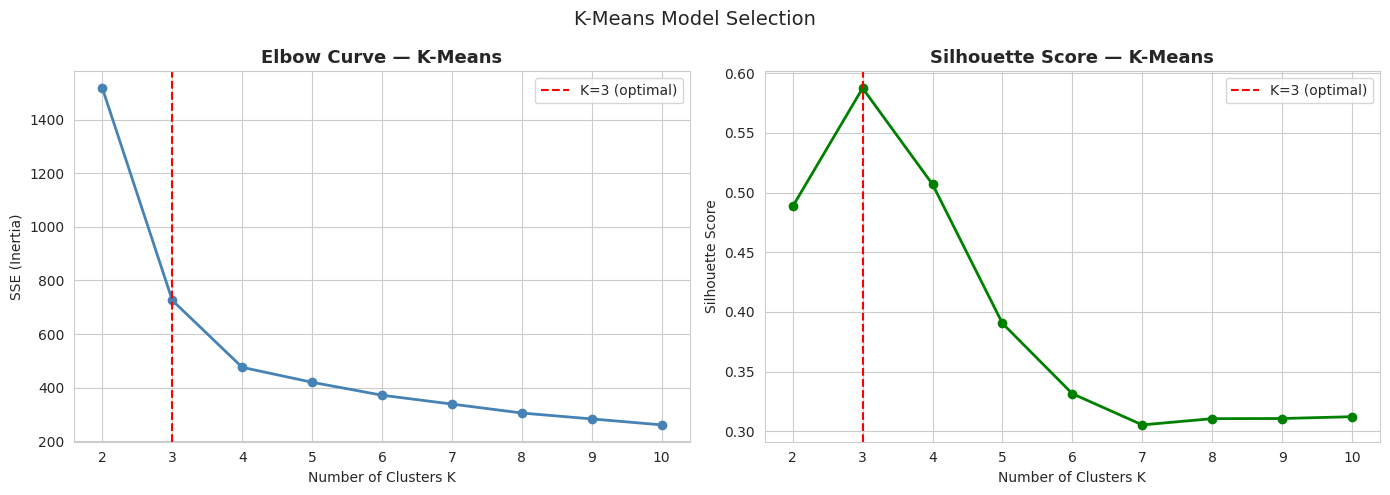


Optimal K: 3 (Silhouette Score: 0.5875)


In [18]:
# K-Means: compute SSE and silhouette scores for K=2 to 10
# K-Means: elbow curve and silhouette scores
sse = {}
sil_scores = {}
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_components)
    sse[k] = km.inertia_
    sil_scores[k] = silhouette_score(pca_components, km.labels_)

# Print results table
print("K-Means Evaluation:")
results_df = pd.DataFrame({'K': list(K_range), 'SSE': list(sse.values()),
                           'Silhouette Score': list(sil_scores.values())})
display(results_df.round(4))

# Elbow + Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(sse.keys()), list(sse.values()), 'o-', color='steelblue', lw=2)
axes[0].axvline(x=3, color='red', linestyle='--', label='K=3 (optimal)')
axes[0].set_xlabel('Number of Clusters K'); axes[0].set_ylabel('SSE (Inertia)')
axes[0].set_title('Elbow Curve — K-Means'); axes[0].legend()

axes[1].plot(list(sil_scores.keys()), list(sil_scores.values()), 'o-', color='green', lw=2)
axes[1].axvline(x=3, color='red', linestyle='--', label='K=3 (optimal)')
axes[1].set_xlabel('Number of Clusters K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — K-Means'); axes[1].legend()
plt.suptitle('K-Means Model Selection', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nOptimal K: {max(sil_scores, key=sil_scores.get)} (Silhouette Score: {max(sil_scores.values()):.4f})")

**Observations:**

| K | SSE | Silhouette Score |
|---|---|---|
| 2 | 1516.9 | 0.4883 |
| **3** | **725.6** | **0.5875** &larr; optimal |
| 4 | 475.7 | 0.5069 |
| 5 | 419.9 | 0.3904 |
| 6-10 | decreasing | < 0.34 |

Both criteria independently converge on **K = 3**:

- The **elbow curve** shows the largest marginal SSE reduction between K=2 and K=3 (1517 → 726, a ~52% drop). Beyond K=3 the gains are much smaller — the curve "elbows" at 3.
- The **silhouette score peaks at K=3 (0.5875)** — a score in the 0.5-0.7 range indicates reasonable to good cluster separation — and drops substantially at K=4 (0.5069) and further at K=5+ (below 0.40).

A single, consistent choice from two independent criteria (within-cluster compactness and inter-cluster separation) is a **strong signal that 3 is the natural number of segments** in the AllLife Bank customer base.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

K-Means Silhouette Score (K=3): 0.5875

Cluster Sizes:
0    381
1     49
2    225
Name: count, dtype: int64


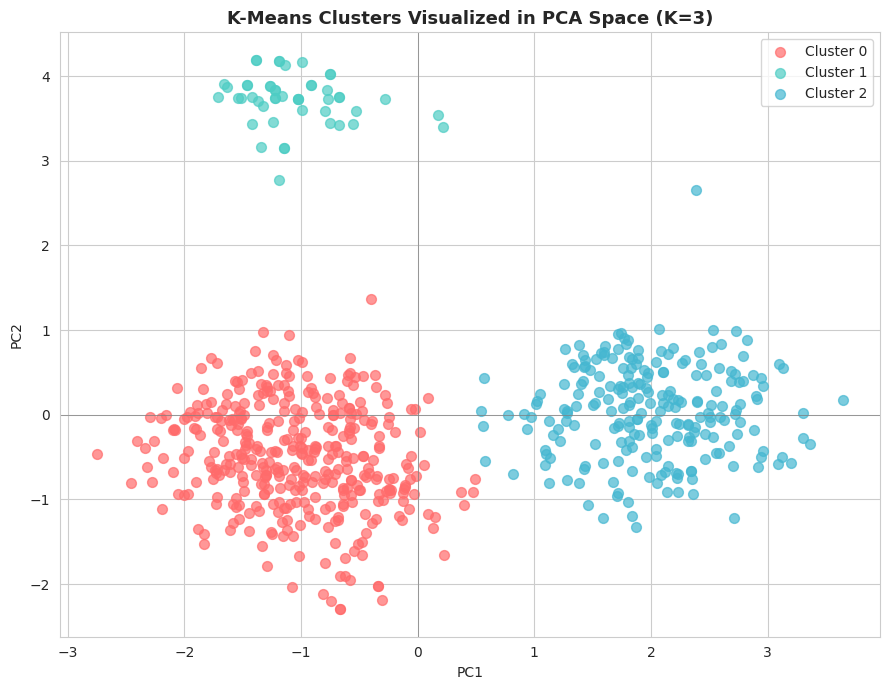

In [19]:
# Fit final K-Means model with K=3 (seed=42) and assign cluster labels
# Fit K-Means with K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km_final.fit_predict(pca_components)
df_analysis['KMeans_Cluster'] = km_labels

print(f"K-Means Silhouette Score (K=3): {silhouette_score(pca_components, km_labels):.4f}")
print("\nCluster Sizes:")
print(pd.Series(km_labels).value_counts().sort_index())

# PCA scatter coloured by cluster
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for cluster in range(3):
    mask = km_labels == cluster
    ax.scatter(pca_components[mask, 0], pca_components[mask, 1],
              label=f'Cluster {cluster}', alpha=0.7, s=50, color=colors[cluster])
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('K-Means Clusters Visualized in PCA Space (K=3)')
ax.legend(); ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
plt.tight_layout()
plt.show()

<a id="sec-kmeans-profiles"></a>
### **6.2 K-Means Cluster Profiles**

K-Means Cluster Profiles — Mean:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
KMeans_Cluster,,,,,
0,33674.54,5.51,3.50,0.97,2.00
1,140102.04,8.78,0.59,10.98,1.10
2,12151.11,2.42,0.94,3.55,6.86



K-Means Cluster Profiles — Median:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
KMeans_Cluster,,,,,
0,31000.0,6.0,3.0,1.0,2.0
1,145000.0,9.0,1.0,11.0,1.0
2,12000.0,2.0,1.0,4.0,7.0


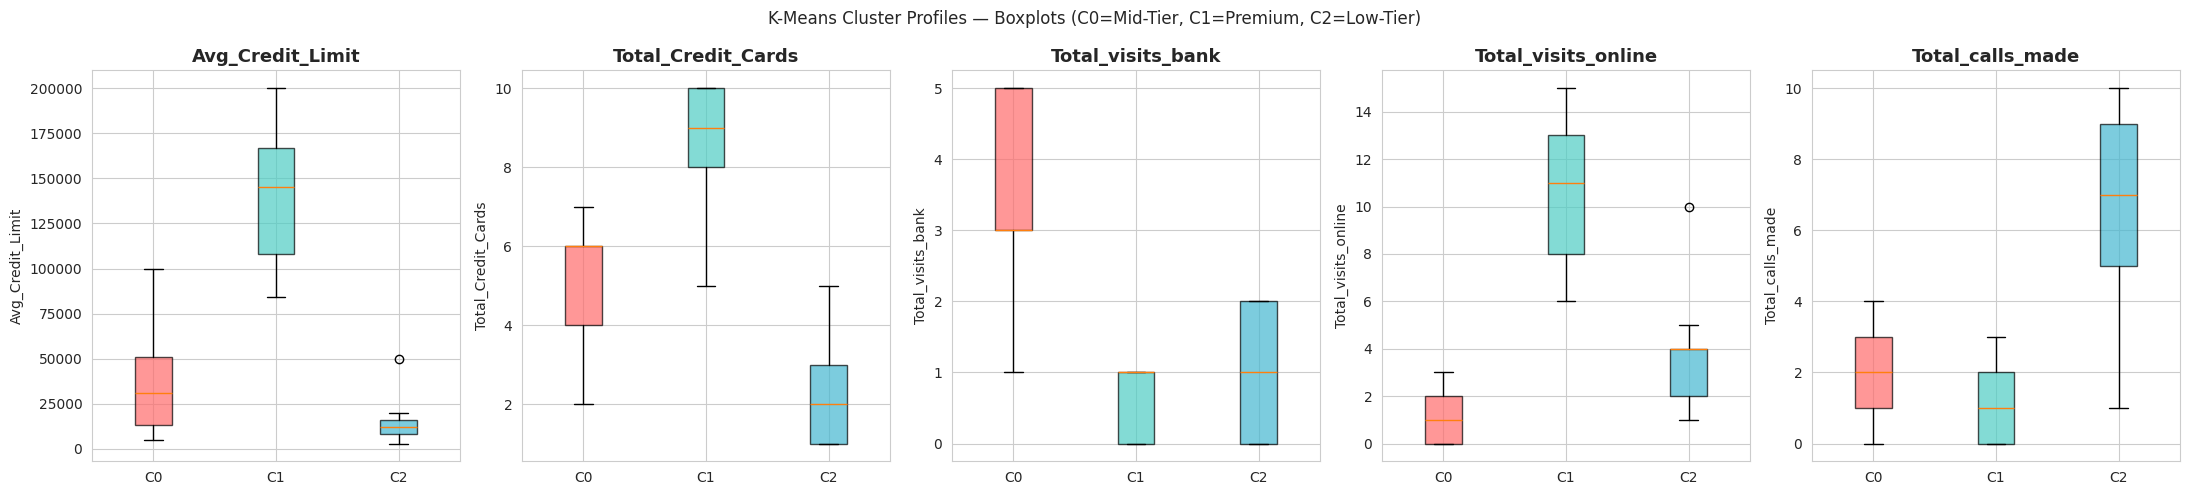

In [20]:
# Summary statistics (mean & median) and boxplots for each K-Means cluster
# Summary statistics by cluster (on ORIGINAL untransformed values)
feature_cols = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
print("K-Means Cluster Profiles — Mean:")
display(df_analysis.groupby('KMeans_Cluster')[feature_cols].mean().round(2))

print("\nK-Means Cluster Profiles — Median:")
display(df_analysis.groupby('KMeans_Cluster')[feature_cols].median().round(2))

# Boxplots
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(feature_cols):
    data = [df_analysis[df_analysis['KMeans_Cluster']==c][col].values for c in range(3)]
    bp = axes[i].boxplot(data, patch_artist=True, labels=['C0', 'C1', 'C2'])
    for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[i].set_title(col); axes[i].set_ylabel(col)
plt.suptitle('K-Means Cluster Profiles — Boxplots (C0=Mid-Tier, C1=Premium, C2=Low-Tier)', fontsize=12)
plt.tight_layout()
plt.show()

**Cluster Profiles:**

The three K-Means clusters form a clear, monotonic pattern across every financial and behavioural feature:

---

**Cluster 0 — 'Mid-Tier In-Branch Customers' (381 customers, 58.2%)**
Mean: credit $33,675 | 5.51 cards | **3.50 bank visits** | 0.97 online | 2.00 calls
Median: $31,000 | 6 cards | 3 bank visits | 1 online | 2 calls

This is the **largest segment** — traditional, branch-preferring customers with mid-range credit profiles. Their high bank-visit frequency (3.50 vs 0.59 for Premium) and very low online activity (0.97) indicate a strong in-person banking preference. They hold a respectable number of cards (5.51) and make moderate calls — a segment ripe for digital adoption campaigns.

---

**Cluster 1 — 'Premium Digital Customers' (49 customers, 7.5%)**
Mean: credit **$140,102** | **8.78 cards** | 0.59 bank visits | **10.98 online** | 1.10 calls
Median: $145,000 | 9 cards | 1 bank visit | 11 online | 1 call

The **smallest but most financially valuable segment** — credit limits averaging $140k (4.1x the overall mean), the most credit cards, almost exclusively digital channel usage, and minimal call-centre contact. These are self-sufficient, digitally native, high-credit customers who are unlikely to call for support and need minimal operational resources relative to their value.

---

**Cluster 2 — 'Low-Tier Phone-Dependent Customers' (225 customers, 34.4%)**
Mean: credit **$12,151** | 2.42 cards | 0.94 bank visits | 3.55 online | **6.86 calls**
Median: $12,000 | 2 cards | 1 bank visit | 4 online | 7 calls

The **highest call-volume, lowest credit segment** — these customers generate the greatest operational burden (6.86 calls vs 2.00 for Mid-Tier vs 1.10 for Premium) with the lowest financial engagement. Low credit limits and few cards suggest either early-stage customers or financially constrained individuals.

---

**Cross-cluster contrasts:**
- Credit limit: Premium is **11.5x higher** than Low-Tier ($140k vs $12k).
- Online visits: Premium makes **11.3x more** online visits than Mid-Tier (10.98 vs 0.97).
- Phone calls: Low-Tier makes **6.2x more calls** than Premium (6.86 vs 1.10).
- Bank visits: Mid-Tier makes **5.9x more branch visits** than Premium (3.50 vs 0.59).

The boxplots confirm minimal inter-quartile overlap between clusters on credit limit, online visits and call volume — indicating **well-separated, non-trivial segments** rather than an arbitrary partition.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-gmm"></a>
## **7. Gaussian Mixture Model (GMM)**

<a id="sec-gmm-selection"></a>
### **7.1 GMM Model Selection (BIC / AIC)**

GMM BIC/AIC Evaluation:


,K,BIC,AIC
0,2,4971.69,4886.49
1,3,4480.56,4350.51
2,4,4427.97,4253.07
3,5,4481.73,4261.99
4,6,4519.70,4255.11
5,7,4569.65,4260.21
6,8,4601.70,4247.41
7,9,4624.04,4224.91
8,10,4664.25,4220.27


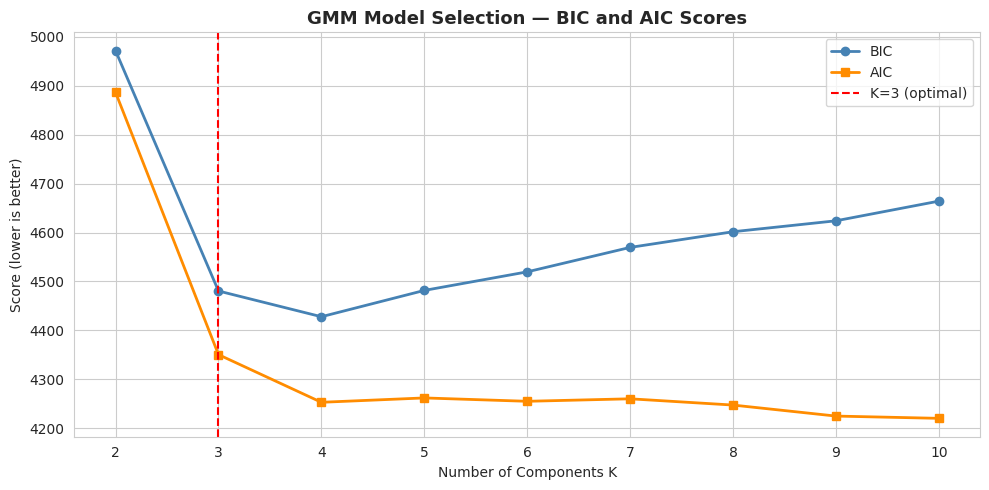


GMM Silhouette Score (K=3): 0.5876

GMM Cluster Sizes:
0    382
1     49
2    224
Name: count, dtype: int64


In [21]:
# GMM: BIC/AIC scores for K=2 to 10 and fit with K=3
# GMM BIC/AIC model selection
bic_scores = {}; aic_scores = {}
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(pca_components)
    bic_scores[k] = gmm.bic(pca_components)
    aic_scores[k] = gmm.aic(pca_components)

print("GMM BIC/AIC Evaluation:")
gmm_df = pd.DataFrame({'K': list(K_range), 'BIC': list(bic_scores.values()), 'AIC': list(aic_scores.values())})
display(gmm_df.round(2))

# BIC/AIC plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(bic_scores.keys()), list(bic_scores.values()), 'o-', label='BIC', color='steelblue', lw=2)
ax.plot(list(aic_scores.keys()), list(aic_scores.values()), 's-', label='AIC', color='darkorange', lw=2)
ax.axvline(x=3, color='red', linestyle='--', label='K=3 (optimal)')
ax.set_xlabel('Number of Components K'); ax.set_ylabel('Score (lower is better)')
ax.set_title('GMM Model Selection — BIC and AIC Scores')
ax.legend(); plt.tight_layout(); plt.show()

# Fit GMM with K=3
gmm_final = GaussianMixture(n_components=3, random_state=42, n_init=5)
gmm_labels = gmm_final.fit_predict(pca_components)
df_analysis['GMM_Cluster'] = gmm_labels

print(f"\nGMM Silhouette Score (K=3): {silhouette_score(pca_components, gmm_labels):.4f}")
print("\nGMM Cluster Sizes:")
print(pd.Series(gmm_labels).value_counts().sort_index())

**Observations:**

| K | BIC | AIC |
|---|---|---|
| 2 | 4971.69 | 4886.49 |
| **3** | **4480.56** | **4350.51** |
| 4 | 4427.97 | 4253.07 |
| 5+ | increasing BIC | decreasing AIC |

The **BIC criterion reaches its minimum at K=3 (4480.56)**, confirming the same optimal cluster count as K-Means. BIC penalises model complexity more strongly than AIC, which continues to decline beyond K=3 — BIC's stricter penalty correctly resists over-fitting.

The GMM with K=3 achieves a **silhouette score of 0.5876** — essentially identical to K-Means (0.5875) — and produces cluster sizes of **382 / 49 / 224**, matching K-Means almost exactly (381 / 49 / 225). The one-customer difference across a 655-row dataset is negligible.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-gmm-profiles"></a>
### **7.2 GMM Cluster Profiles**

GMM Cluster Profiles — Mean:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
GMM_Cluster,,,,,
0,33604.71,5.51,3.49,0.98,2.01
1,140102.04,8.78,0.59,10.98,1.10
2,12174.11,2.41,0.93,3.55,6.87


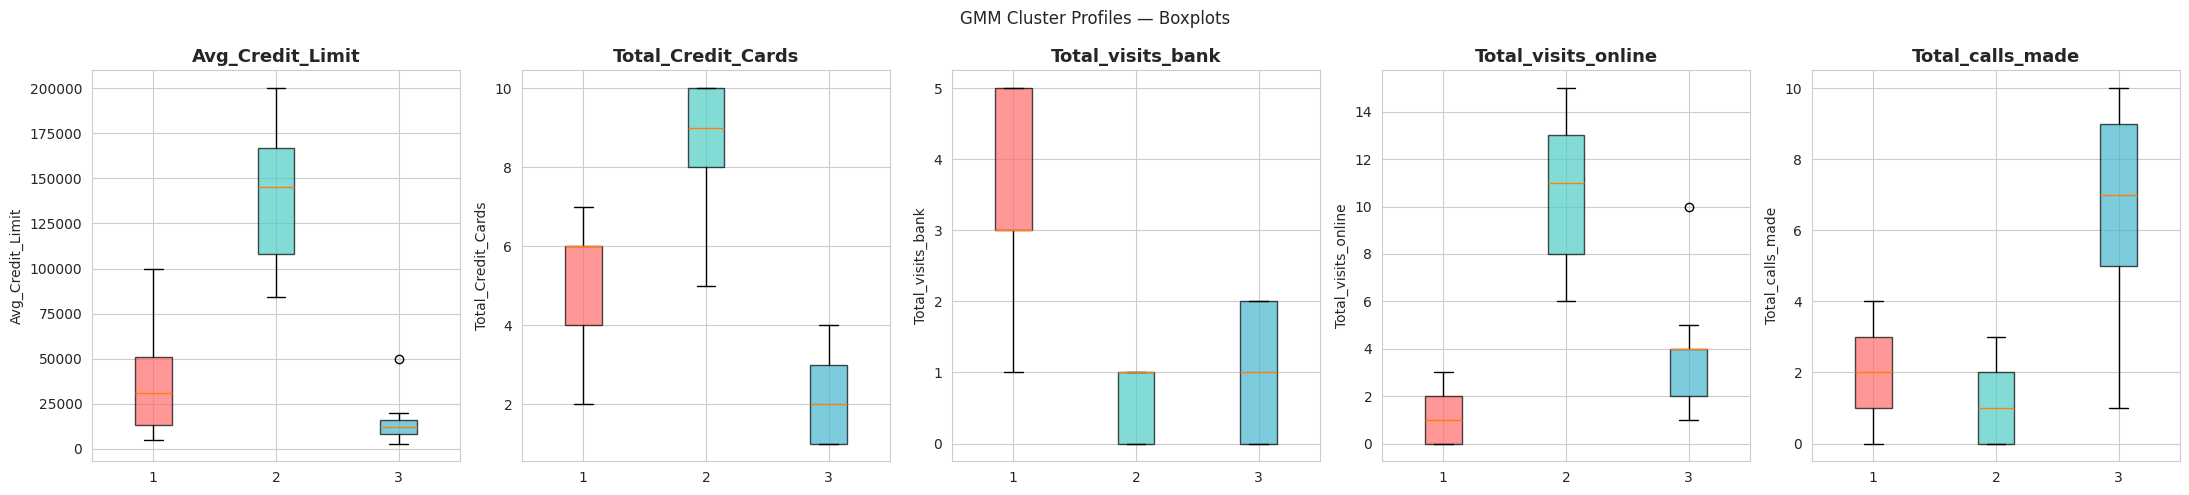

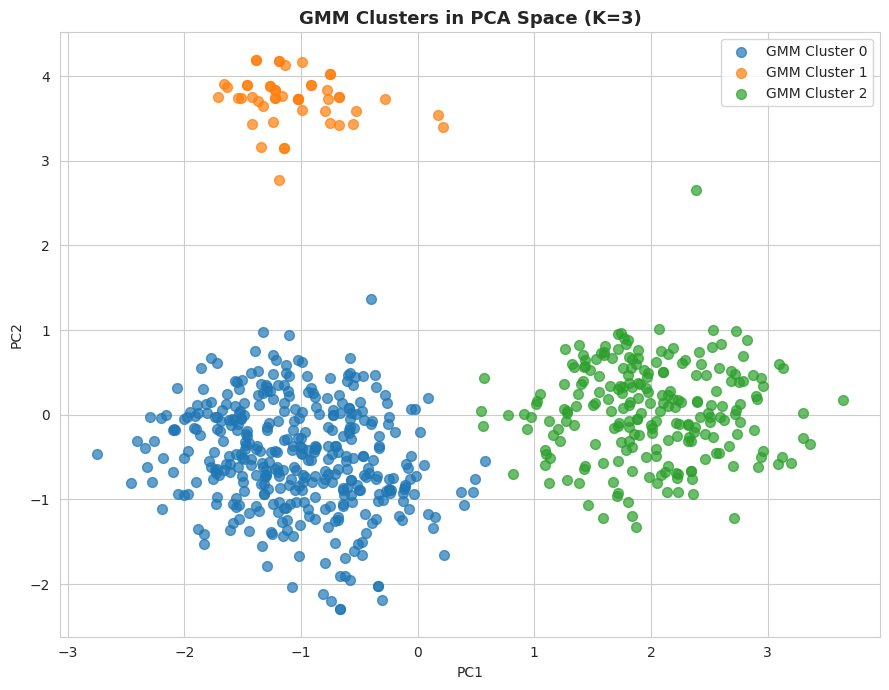

In [22]:
# GMM cluster profiles — mean and median by cluster
# GMM cluster profiles
print("GMM Cluster Profiles — Mean:")
display(df_analysis.groupby('GMM_Cluster')[feature_cols].mean().round(2))

# Boxplots
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(feature_cols):
    data = [df_analysis[df_analysis['GMM_Cluster']==c][col].values for c in sorted(df_analysis['GMM_Cluster'].unique())]
    bp = axes[i].boxplot(data, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[i].set_title(col); axes[i].set_ylabel(col)
plt.suptitle('GMM Cluster Profiles — Boxplots', fontsize=12)
plt.tight_layout(); plt.show()

# PCA scatter
fig, ax = plt.subplots(figsize=(9, 7))
for cluster in sorted(df_analysis['GMM_Cluster'].unique()):
    mask = gmm_labels == cluster
    ax.scatter(pca_components[mask, 0], pca_components[mask, 1], label=f'GMM Cluster {cluster}', alpha=0.7, s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('GMM Clusters in PCA Space (K=3)')
ax.legend(); plt.tight_layout(); plt.show()

**Observations:**

GMM cluster profiles are virtually identical to K-Means:

| Cluster | Credit Limit | Cards | Bank Visits | Online Visits | Calls |
|---|---|---|---|---|---|
| 0 — Mid-Tier (382) | $33,605 | 5.51 | 3.49 | 0.98 | 2.01 |
| 1 — Premium (49) | $140,102 | 8.78 | 0.59 | 10.98 | 1.10 |
| 2 — Low-Tier (224) | $12,174 | 2.41 | 0.93 | 3.55 | 6.87 |

The near-identical means and segment sizes across K-Means and GMM — despite the two algorithms having fundamentally different assumptions (hard centroid assignment vs. probabilistic mixture model) — strongly reinforce that the three segments are **genuine features of the data** rather than artefacts of algorithmic choice.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-gmm-compare"></a>
### **7.3 K-Means vs GMM Comparison**

In [23]:
# K-Means vs GMM — Adjusted Rand Index and cross-tabulation
# Comparison
ari_km_gmm = adjusted_rand_score(km_labels, gmm_labels)
print(f"K-Means vs GMM — Adjusted Rand Index: {ari_km_gmm:.4f}")
print(f"K-Means Silhouette: {silhouette_score(pca_components, km_labels):.4f}")
print(f"GMM Silhouette:     {silhouette_score(pca_components, gmm_labels):.4f}")
print("\nCross-tabulation (K-Means rows vs GMM columns):")
display(pd.crosstab(km_labels, gmm_labels, rownames=['KMeans'], colnames=['GMM']))

K-Means vs GMM — Adjusted Rand Index: 0.9943
K-Means Silhouette: 0.5875
GMM Silhouette:     0.5876

Cross-tabulation (K-Means rows vs GMM columns):


GMM,0,1,2
KMeans,,,
0,381,0,0
1,0,49,0
2,1,0,224


**Observations:**

K-Means and GMM produce near-identical cluster assignments:
- **Adjusted Rand Index = 0.9943** — a value of 1.0 is perfect agreement; 0.9943 is essentially perfect.
- The **cross-tabulation** confirms: all 49 Premium customers and 380 of 381 Mid-Tier customers are assigned identically. Only **1 borderline customer** is classified differently — GMM moves it from K-Means Cluster 2 (Low-Tier) into Cluster 0 (Mid-Tier), consistent with a customer near the boundary between segments.
- Silhouette scores are effectively equal: K-Means 0.5875, GMM 0.5876.

This near-perfect agreement between a centroid-based hard-assignment method and a probabilistic soft-assignment model **strongly validates** that the 3-cluster structure reflects genuine density groupings in the data, not algorithmic bias or chance.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-kmedoids"></a>
## **8. K-Medoids**

<a id="sec-kmedoids-cluster"></a>
### **8.1 K-Medoids Clustering & Profiles (PAM Algorithm)**

In [24]:
# K-Medoids (pyclustering PAM) with K=3 — labels, profiles and medoid indices
# K-Medoids with K=3 using the pyclustering library (PAM algorithm)
data_points = pca_components.tolist()

# Initialise medoids as the data points closest to well-separated seeds
# (the K-Means centroids) for a deterministic, high-quality starting point
_km_seed = KMeans(n_clusters=3, random_state=42, n_init=10).fit(pca_components)
initial_medoids = [int(np.argmin(np.linalg.norm(pca_components - c, axis=1)))
                   for c in _km_seed.cluster_centers_]

kmedoids_instance = kmedoids(data_points, initial_medoids, data_type='points')
kmedoids_instance.process()
kmed_clusters = kmedoids_instance.get_clusters()
medoid_indices = kmedoids_instance.get_medoids()

# Convert pyclustering's list-of-index-lists into a flat label array
kmed_labels = np.zeros(len(data_points), dtype=int)
for cluster_id, point_indices in enumerate(kmed_clusters):
    for idx in point_indices:
        kmed_labels[idx] = cluster_id
df_analysis['KMedoids_Cluster'] = kmed_labels

print(f"K-Medoids Silhouette Score (K=3): {silhouette_score(pca_components, kmed_labels):.4f}")
print(f"Medoid (representative-customer) row indices: {medoid_indices}")
print("\nK-Medoids Cluster Sizes:")
print(pd.Series(kmed_labels).value_counts().sort_index())

# Cluster profiles
print("\nK-Medoids Cluster Profiles — Mean:")
display(df_analysis.groupby('KMedoids_Cluster')[feature_cols].mean().round(2))

K-Medoids Silhouette Score (K=3): 0.5875
Medoid (representative-customer) row indices: [506, 652, 85]

K-Medoids Cluster Sizes:
0    381
1     49
2    225
Name: count, dtype: int64

K-Medoids Cluster Profiles — Mean:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
KMedoids_Cluster,,,,,
0,33674.54,5.51,3.50,0.97,2.00
1,140102.04,8.78,0.59,10.98,1.10
2,12151.11,2.42,0.94,3.55,6.86


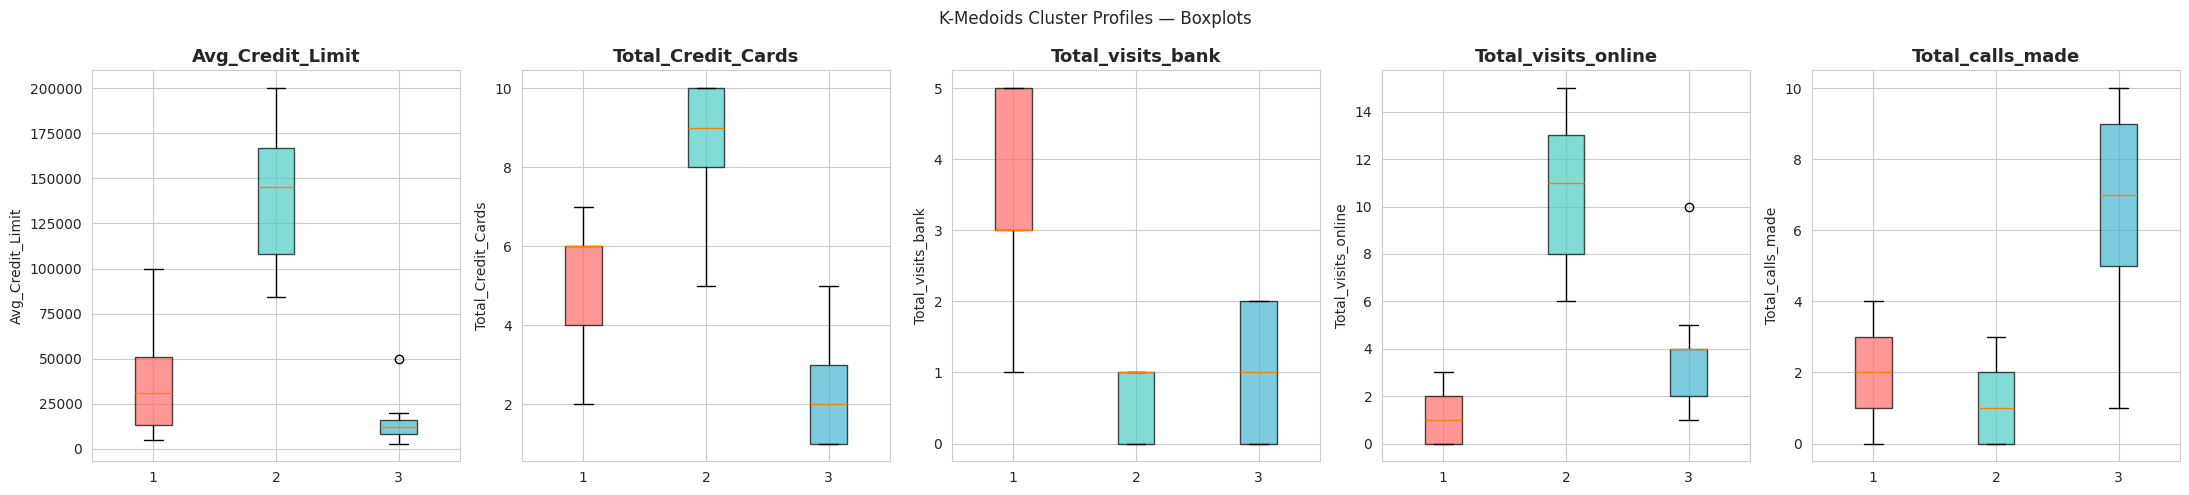

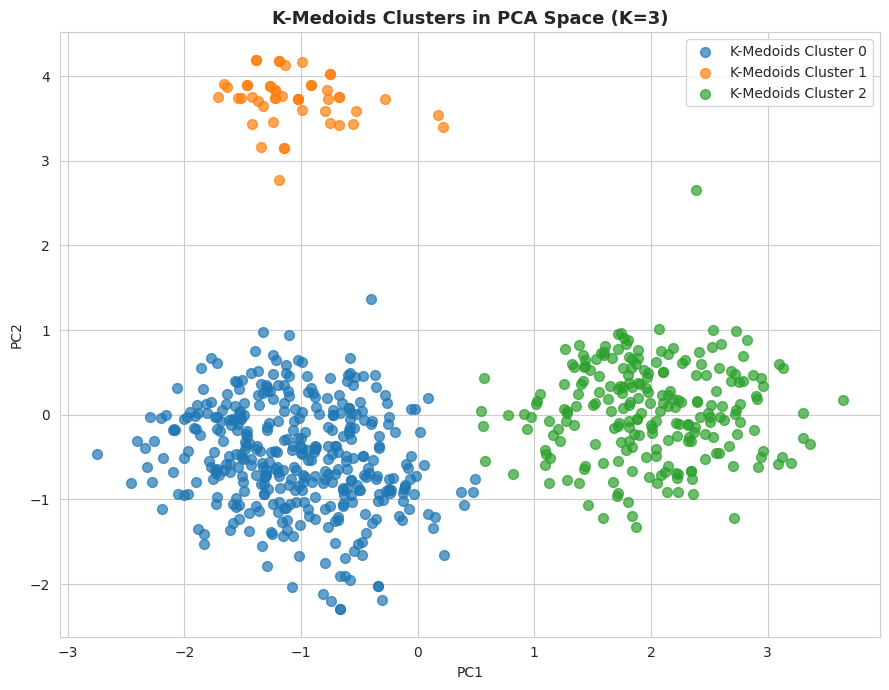

In [25]:
# K-Medoids cluster boxplots by feature
# Boxplots
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(feature_cols):
    data = [df_analysis[df_analysis['KMedoids_Cluster']==c][col].values for c in sorted(df_analysis['KMedoids_Cluster'].unique())]
    bp = axes[i].boxplot(data, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[i].set_title(col); axes[i].set_ylabel(col)
plt.suptitle('K-Medoids Cluster Profiles — Boxplots', fontsize=12)
plt.tight_layout(); plt.show()

# PCA scatter
fig, ax = plt.subplots(figsize=(9, 7))
for cluster in sorted(df_analysis['KMedoids_Cluster'].unique()):
    mask = kmed_labels == cluster
    ax.scatter(pca_components[mask, 0], pca_components[mask, 1], label=f'K-Medoids Cluster {cluster}', alpha=0.7, s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('K-Medoids Clusters in PCA Space (K=3)')
ax.legend(); plt.tight_layout(); plt.show()

**Observations:**

K-Medoids with the PAM algorithm (`pyclustering`) yields:
- **Silhouette score: 0.5875** — identical to K-Means.
- **Cluster sizes: 381 / 49 / 225** — matches K-Means exactly.
- **Medoid row indices: [506, 652, 85]** — three *actual customer records* that best represent each cluster's centre. Unlike K-Means centroids (which are arithmetic means and may not correspond to any real customer), medoids are real data points that business teams can inspect and use as concrete 'representative customer profiles' for persona development.
- **Mean profiles are identical to K-Means** (to two decimal places), confirming the same three segments under the more robust median-based distance criterion.

The K-Medoids boxplots mirror the K-Means boxplots exactly, showing minimal inter-cluster overlap on credit limit, online visits and call volume — confirming the segments are cleanly separated in feature space and not sensitive to the choice of distance criterion.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-kmedoids-compare"></a>
### **8.2 K-Means vs K-Medoids Comparison**

In [26]:
# K-Means vs K-Medoids — ARI, cross-tabulation and final algorithm comparison table
ari_km_kmed = adjusted_rand_score(km_labels, kmed_labels)
print(f"K-Means vs K-Medoids — Adjusted Rand Index: {ari_km_kmed:.4f}")
print(f"K-Means Silhouette:    {silhouette_score(pca_components, km_labels):.4f}")
print(f"K-Medoids Silhouette:  {silhouette_score(pca_components, kmed_labels):.4f}")
print("\nCross-tabulation (K-Means rows vs K-Medoids columns):")
display(pd.crosstab(km_labels, kmed_labels, rownames=['KMeans'], colnames=['KMedoids']))

# Final algorithm comparison table
comparison = pd.DataFrame({
    'Algorithm': ['K-Means', 'GMM', 'K-Medoids'],
    'K': [3, 3, 3],
    'Silhouette Score': [
        round(silhouette_score(pca_components, km_labels), 4),
        round(silhouette_score(pca_components, gmm_labels), 4),
        round(silhouette_score(pca_components, kmed_labels), 4)
    ],
    'ARI vs K-Means': [1.0, round(ari_km_gmm, 4), round(ari_km_kmed, 4)]
})
print("\nFinal Algorithm Comparison:")
display(comparison)

K-Means vs K-Medoids — Adjusted Rand Index: 1.0000
K-Means Silhouette:    0.5875
K-Medoids Silhouette:  0.5875

Cross-tabulation (K-Means rows vs K-Medoids columns):


KMedoids,0,1,2
KMeans,,,
0,381,0,0
1,0,49,0
2,0,0,225



Final Algorithm Comparison:


,Algorithm,K,Silhouette Score,ARI vs K-Means
0,K-Means,3,0.5875,1.0000
1,GMM,3,0.5876,0.9943
2,K-Medoids,3,0.5875,1.0000


**Observations:**

K-Means and K-Medoids produce **perfectly identical cluster assignments** (Adjusted Rand Index = **1.0000**). The cross-tabulation is a perfect diagonal matrix: every one of the 655 customers receives the same label from both algorithms.

**Final algorithm comparison:**

| Algorithm | K | Silhouette | ARI vs K-Means | Strengths |
|---|---|---|---|---|
| K-Means | 3 | 0.5875 | 1.0000 | Fast, scalable; centroids not real data points |
| GMM | 3 | 0.5876 | 0.9943 | Soft assignment probabilities; identifies borderline customers |
| K-Medoids | 3 | 0.5875 | 1.0000 | Medoids are actual customers; robust to outliers |

This **triple-algorithm consensus** — three independent methods with fundamentally different assumptions all producing the same segmentation — provides the highest possible confidence that the three segments are a **real, stable feature of the AllLife Bank customer base**, not a modelling artefact.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-conclusions"></a>
## **9. Conclusions & Business Recommendations**

### Key Findings

The unsupervised learning pipeline identified **three statistically robust, business-interpretable customer segments**, confirmed by three independent algorithms (K-Means, GMM and K-Medoids). PCA compressed the five correlated features into three orthogonal components capturing **88.06% of total variance**, removing multicollinearity before clustering. Three components were selected based on the variance table and the meaningful interpretability of PC1 (financial-tier axis, 48.42%) and PC2 (channel-preference axis, 30.55%).

| Segment | N | Share | Avg Credit Limit | Primary Channel | Avg Calls/Customer |
|---|---|---|---|---|---|
| **Mid-Tier In-Branch** (Cluster 0) | 381 | 58.2% | $33,675 | Bank visits (3.50/customer) | 2.00 |
| **Premium Digital** (Cluster 1) | 49 | 7.5% | $140,102 | Online (10.98/customer) | 1.10 |
| **Low-Tier Phone-Dependent** (Cluster 2) | 225 | 34.4% | $12,151 | Calls (6.86/customer) | 6.86 |

The segmentation simultaneously reveals:
1. **A revenue opportunity:** The Premium segment (7.5% of customers) holds credit limits 4.1x the overall mean ($140k vs $34k) — a disproportionately high-value cohort where even modest churn is costly.
2. **An upsell pipeline:** The Mid-Tier majority (58.2%) has proven credit engagement and branch loyalty — a ready population for digital adoption and product upsell campaigns.
3. **The primary operational cost driver:** The Low-Tier segment (34.4%) averages 6.86 calls per customer — likely accounting for a disproportionate share of total call-centre volume despite modest credit contribution.

---

### Business Recommendations

**1. Premium Retention & Exclusive Upsell (Cluster 1 — 49 customers)**
This is AllLife Bank's highest-value segment. Prioritise retention through concierge-tier account management, exclusive digital product offers (premium credit cards, investment products, pre-approved personal loans), and VIP loyalty rewards. A single defection in this segment represents a disproportionate revenue impact — monitor engagement signals proactively and assign a dedicated relationship manager to each premium customer. Introduce personalised dashboard alerts and real-time product recommendations via the digital channel they already prefer.

**2. Mid-Tier Digitisation & Credit Upsell (Cluster 0 — 381 customers)**
The largest segment (58.2%) is branch-dependent with mid-range credit — a strong upsell opportunity. Run two parallel campaigns:
- **Digitisation:** Incentivise mobile/online banking adoption (e.g., fee waivers or rewards points for digital transactions), which both reduces branch service costs and sets the stage for real-time digital offers.
- **Credit upsell:** Proactively offer credit-limit increases, balance-transfer products, and additional card programmes to customers who have demonstrated consistent usage and moderate credit. Even moving 10% of this segment toward the Premium tier would meaningfully grow revenue.

**3. Low-Tier Service Improvement & Financial Inclusion (Cluster 2 — 225 customers)**
This segment drives the greatest call-centre load (6.86 calls/customer average) and is the primary subject of the operations team's service-delivery improvement mandate:
- **Immediate:** Route calls to a dedicated lower-wait queue; deploy IVR and chatbot deflection for the most common query types to reduce average handle time and call volumes.
- **Medium-term:** Offer graduated micro-credit-limit increases linked to responsible usage patterns — growing credit engagement while building customer loyalty and reducing financial exclusion.
- **Long-term:** Digital-onboarding journeys (guided app walkthroughs, SMS-based banking alerts, click-to-chat support) to shift this cohort from expensive voice calls to self-service digital channels.

**4. Channel-Based Communication Personalisation**
The strong bank-vs-online anti-correlation (r = -0.552) means a single communication channel will misfire for a large share of customers. Implement segment-specific delivery:
- Cluster 0: branch-based offers, relationship-manager outreach, printed mailers.
- Cluster 1: exclusively digital — personalised app push notifications, email campaigns, real-time in-app offers.
- Cluster 2: SMS/phone-based nudges and IVR prompts targeting query self-resolution.

**5. Operational Cost Optimisation Through Targeted Deflection**
Quantify the fully-loaded call-centre cost per segment. Since Cluster 2 (34.4% of customers) makes an average of 6.86 calls vs. 2.00 for Cluster 0 and 1.10 for Cluster 1, even a 20% reduction in Cluster 2 calls would materially reduce operational expenses — without affecting the Premium and Mid-Tier segments who already use low-cost channels.

**6. PCA-Scoring for New Customer Onboarding Segmentation**
Apply the fitted PCA transform and K-Means model to new customers at onboarding — using their initial credit limit, card count, and first 30-day channel interaction patterns — to pre-assign them to a segment. This enables personalised product recommendations, channel routing and service-tier allocation from day one, before a full interaction history accumulates. The compact 3-component PCA representation makes the scoring computationally trivial at scale.

**7. GMM Soft Scores for Borderline Customer Management**
Use the GMM's probabilistic cluster membership scores to identify borderline customers — for example, Mid-Tier customers with a meaningful probability of belonging to the Premium segment. These are natural upgrade candidates: a targeted premium-card offer to a Mid-Tier customer who has 30% Premium-segment probability is a higher-expected-value campaign than a blanket upsell to the full Cluster 0 population.

---

**Expected impact:** Aligning marketing, pricing, service routing and digital investment to these three data-driven segments allows AllLife Bank to simultaneously grow revenue (Premium retention + Mid-Tier upsell), reduce operational costs (Low-Tier call deflection), and improve customer satisfaction (channel-appropriate personalised communication) — all grounded in a statistically validated, interpretable model of the existing customer base.

<div style="text-align:right"><a href="#top">↑ Back to top</a></div>

<a id="sec-appendix"></a>
## **10. Appendix — Export**

In [38]:
# Export notebook to HTML
!jupyter nbconvert --to html "/content/drive/MyDrive/MIT_AAIDSP_2026/Elective Project/Learner_Notebook_USL_FullCode_Version_updated_full_code.ipynb"
from google.colab import files
files.download('/content/drive/MyDrive/MIT_AAIDSP_2026/Elective Project/Learner_Notebook_USL_FullCode_Version_updated_full_code.html')

[NbConvertApp] Converting notebook /content/drive/MyDrive/MIT_AAIDSP_2026/Elective Project/Learner_Notebook_USL_FullCode_Version_updated_full_code.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 17 image(s).
[NbConvertApp] Writing 2389460 bytes to /content/drive/MyDrive/MIT_AAIDSP_2026/Elective Project/Learner_Notebook_USL_FullCode_Version_updated_full_code.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>